In [1]:
#SCALAR GAUSS BONNET MODIFIED EXAMPLE

# Isotropic Schwarzschild BH example
# see further details in https://github.com/GRChombo/engrenage/wiki/Running-the-black-hole-example

# restart the kernel to clear past work
# (can also do this manually from the Kernel options above)
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

In [2]:
# load the required python modules
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import time
import sys
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

# homemade source code from source folder
sys.path.append('/Users/serdaryildiz/Desktop/GRSerdar/engrenage/source')

from initialdata.bhinitialconditions import *
from backgrounds.sphericalbackground import *
from bssn.constraintsdiagnostic import *
from bssn.ahfinder import *
from core.rhsevolution import *
from core.grid import Grid
from core.spacing import *
from core.display import *
from core.statevector import *
from matter.scalarmatter import *

In [3]:
# Set up the chosen matter class
scalar_mu = 1.0
my_matter = ScalarMatter(scalar_mu)
my_state_vector = StateVector(my_matter)

# Input parameters for grid and evolution here
r_max = 96.0 # outer edge of the grid (including ghosts)
#min_dr = 1 / 16 # roughly 32 points across the BH

min_dr = 1/16
#min_dr = 1 / 64
max_dr = 2

# SinhSpacing
# params = SinhSpacing.get_parameters(r_max, min_dr, max_dr)
# spacing = SinhSpacing(**params)

# CubicSpacing
params = CubicSpacing.get_parameters(r_max, min_dr, max_dr)
spacing = CubicSpacing(**params)

grid = Grid(spacing, my_state_vector)
r = grid.r
num_points = r.size
background = FlatSphericalBackground(r)

# Check grid params
print(params)

#########################################################################################

initial_state = get_initial_state(grid, background)

#unpackage the vector for readability
(initial_phi, initial_hrr, initial_htt, initial_hpp, 
 initial_K, initial_arr, initial_att, initial_app, 
 initial_lambdar, initial_shiftr, initial_br, initial_lapse, 
 initial_u, initial_v) = np.array_split(initial_state, grid.NUM_VARS)

#########################################################################################

# Check that for a higher resolution the Ham constraint converges (the Mom constraint is trivially zero)

# Input parameters for HR grid
min_dr_HR = 1 / 32 # roughly 64 points across the BH
max_dr_HR = 1

# CubicSpacing
params_HR = CubicSpacing.get_parameters(r_max, min_dr_HR, max_dr_HR)
spacing_HR = CubicSpacing(**params_HR)

grid_HR = Grid(spacing_HR, my_state_vector)
r_HR = grid_HR.r
num_points_HR = r_HR.size
background_HR = FlatSphericalBackground(r_HR)

# Check grid params
print(params_HR)

# Get initial state
initial_state_HR = get_initial_state(grid_HR, background_HR)

{'r_max': 96.0, 'extent': <SpacingExtent.HALF: 0>, 'a': 1.5213625583444466, 'num_points': 140}
{'r_max': 96.0, 'extent': <SpacingExtent.HALF: 0>, 'a': 1.5213625583444466, 'num_points': 275}


# Start running the simulation

In [4]:
# for control of time integrator and spatial grid
#T = 10 # Maximum evolution time
T = 10
#num_points_t = 128 # time resolution (only for outputs, not for integration, which is decided by python)
num_points_t = 250

# Work out dt and time spacing of outputs
dt = T/num_points_t
t = np.linspace(0, T-dt, num_points_t)

# Solve for the solution using RK45 integration of the ODE
# to make like (older) python odeint method use method='LSODA' instead
# use tqdm package to track progress
with tqdm(total=1000, unit="‰") as progress_bar:
    dense_solution = solve_ivp(get_rhs, [0,T], initial_state, 
                               args=(grid, background, my_matter, progress_bar, [0, T/1000]),
                        #atol=1e-5, rtol=1e-5,
                        max_step = 0.4 * min_dr, #for stability and for KO coeff of 1
                        method='RK45', dense_output=True)

# Interpolate the solution at the time points requested
solution = dense_solution.sol(t).T

  0%|          | 0/1000 [00:00<?, ?‰/s]

# Kretschmann scalar VS LGB term

The coordinate transformation to go from Schwarzschild ($r$) to isotropic ($R$) coordinates

$r = R \left( 1+\frac{(M)^2}{4R}\right)$

In Schwarzschil coordinates the K scalar is given by

$K = \frac{48}{r^6}$

Hence what we need

$K = \frac{48}{\left(R \left( 1+\frac{(M)^2}{4R}\right)\right)^6}$

The K scalar is equal to the GB term at first order (if we neglect backreaction)

 

In [5]:
# To obtain the scalar K in iso SZ coordinates

def iso_to_sz(R):
    return R*(1+ 1/(2*R))**2
    
def Kretschmann(r):
    return 48/(r**6)

# Comparing the Kretschman scalar with gaussbonnet term 

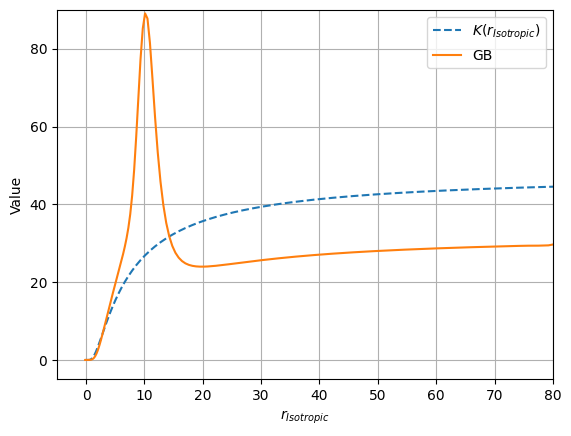

In [11]:
idx= -1# time index
#idx = 0 #initial time 

Gausser = Gaur[idx]
line1 = LLine1[idx] 
line2 = LLine2[idx]
line3 = LLine3[idx]
line4 = LLine4[idx]

plt.plot(r, Kretschmann(iso_to_sz(r))*r**6, label='$K(r_{Isotropic})$', linestyle='--')

'''plt.plot(r, line1*r**6, label = 'line1')
plt.plot(r, line2*r**6, label = 'line2')
plt.plot(r, line3*r**6, label = 'line3')
plt.plot(r, line4*r**6, label = 'line4')
'''

plt.plot(r, Gausser*r**6, label = 'GB', linestyle="-")


plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''

plt.xlim(-5,80)
plt.ylim(-5,90)
plt.grid()

## Line 1

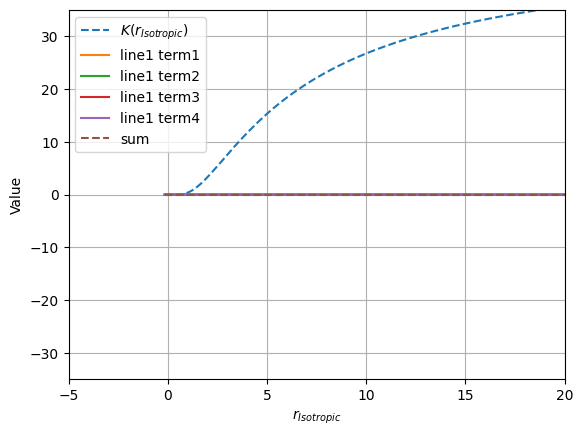

In [11]:
idx= -1# time index
#idx = 0 #initial time 

Gausser = Gaur[idx]
line1 = LLine1[idx] 
line2 = LLine2[idx]
line3 = LLine3[idx]
line4 = LLine4[idx]

term1 = line1t1[idx]
term2 = line1t2[idx]
term3 = line1t3[idx]
term4 = line1t4[idx]

somma = term1+ term2+term3+term4



plt.plot(r, Kretschmann(iso_to_sz(r))*r**6, label='$K(r_{Isotropic})$', linestyle='--')

plt.plot(r, term1*r**6, label = 'line1 term1')
plt.plot(r, term2*r**6, label = 'line1 term2')
plt.plot(r, term3*r**6, label = 'line1 term3')
plt.plot(r, term4*r**6, label = 'line1 term4')

#plt.plot(r, Gausser*r**6, label = 'GB', linestyle="-")

plt.plot(r, somma*r**6, label = 'sum', linestyle="--")


plt.legend(loc='best')
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best')
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''

plt.xlim(-5,20)
plt.ylim(-35,35)
plt.grid()

## Line 2

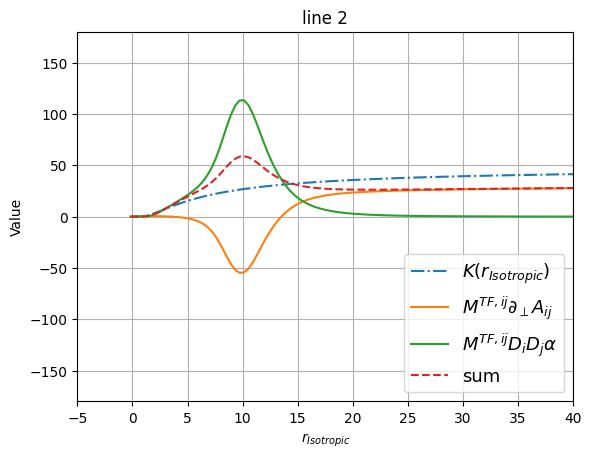

In [12]:
idx= -1 # time index
#idx = 0 #initial time 

dadt_perper = dadt_list[idx] 
DkDl_lapse_Katy = DkDl_lapse_Katy_list[idx]


som = dadt_perper + DkDl_lapse_Katy 



plt.plot(r, Kretschmann(iso_to_sz(r))*r**6, label=r"$K(r_{Isotropic})$", linestyle='-.')

plt.plot(r, dadt_perper*r**6, label = r"$M^{TF, ij} \partial_{\perp}A_{ij}$")
plt.plot(r, DkDl_lapse_Katy*r**6, label = r"$M^{TF, ij}D_i D_j \alpha$")

plt.plot(r, som*r**6, label = 'sum', linestyle="--")




#plt.plot(r, Gausser*r**6, label = 'GB', linestyle="-")

plt.title("line 2")
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best', fontsize=13)
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''

plt.xlim(-5,40)
plt.ylim(-180,180)
plt.grid()

## Line 3

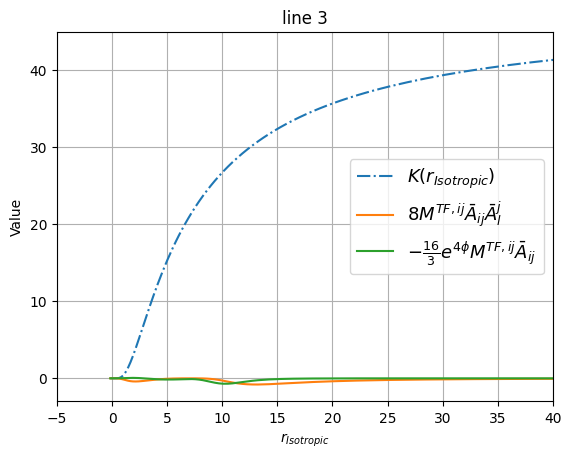

In [13]:
idx= -1 # time index
#idx = 0 #initial time 

ak = ak_list[idx] 
kkk = klist[idx]


som = ak + kkk 



plt.plot(r, Kretschmann(iso_to_sz(r))*r**6, label=r"$K(r_{Isotropic})$", linestyle='-.')

plt.plot(r, ak*r**6, label = r"8$M^{TF, ij} \bar{A}_{ij}\bar{A}^j_l$")
plt.plot(r, kkk*r**6, label = r"$ -\frac{16}{3} e^{4\phi} M^{TF, ij}\bar{A}_{ij}  $")

#plt.plot(r, som*r**6, label = 'sum', linestyle="--")




#plt.plot(r, Gausser*r**6, label = 'GB', linestyle="-")

plt.title("line 3")
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best', fontsize=13)
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''

plt.xlim(-5,40)
plt.ylim(-3,45)
plt.grid()

## Line 2 and 3

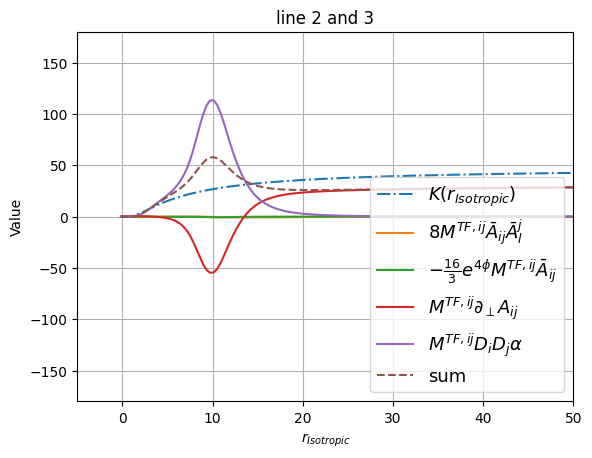

In [14]:
idx= -1 # time index
#idx = 0 #initial time 

ak = ak_list[idx] 
kkk = klist[idx]

dadt_perper = dadt_list[idx] 
DkDl_lapse_Katy = DkDl_lapse_Katy_list[idx]

som = ak + kkk +dadt_perper + DkDl_lapse_Katy 

plt.plot(r, Kretschmann(iso_to_sz(r))*r**6, label=r"$K(r_{Isotropic})$", linestyle='-.')

plt.plot(r, ak*r**6, label = r"8$M^{TF, ij} \bar{A}_{ij}\bar{A}^j_l$")
plt.plot(r, kkk*r**6, label = r"$ -\frac{16}{3} e^{4\phi} M^{TF, ij}\bar{A}_{ij}  $")
plt.plot(r, dadt_perper*r**6, label = r"$M^{TF, ij} \partial_{\perp}A_{ij}$")
plt.plot(r, DkDl_lapse_Katy*r**6, label = r"$M^{TF, ij}D_i D_j \alpha$")

plt.plot(r, som*r**6, label = 'sum', linestyle="--")




#plt.plot(r, Gausser*r**6, label = 'GB', linestyle="-")

plt.title("line 2 and 3")
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best', fontsize=13)
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''

plt.xlim(-5,50)
plt.ylim(-180,180)
plt.grid()

## Line 4

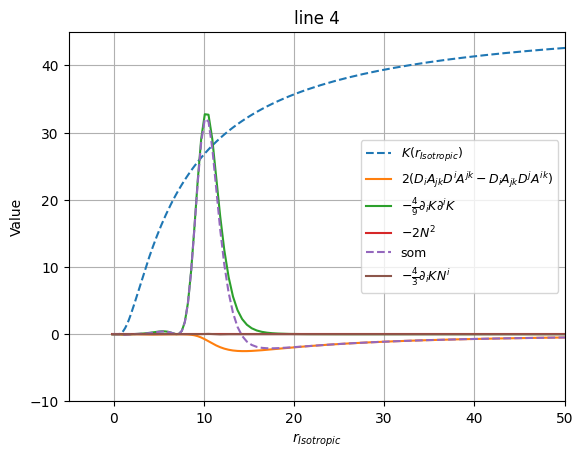

In [15]:
idx= -1 # time index
#idx = 0 #initial time 

D_diff = D_difference[idx] 
D_1 = D_1list[idx]
D_2 = D_1list[idx]
d1K_N_U_item = d1K_N_U[idx]
ff = finalfour[idx]
ff2 = finalfour2[idx]

somm = D_diff +  d1K_N_U_item + ff + ff2


plt.plot(r, Kretschmann(iso_to_sz(r))*r**6, label=r"$K(r_{Isotropic})$", linestyle='--')

plt.plot(r, D_diff*r**6, label = r"$2(D_{i}A_{jk}D^{i}A^{jk}-D_{i}A_{jk}D^{j}A^{ik})$")
#plt.plot(r, D_1*r**6, label = r"$2 D_{i}A_{jk}D^{i}A^{jk}$")
#plt.plot(r, D_2*r**6, label = r"$2 D_{i}A_{jk}D^{j}A^{ik}$", linestyle="--")
plt.plot(r, ff*r**6, label = r"$-\frac{4}{9}\partial_i K \partial^i K$")
plt.plot(r, -d1K_N_U_item*r**6, label = r"$-2N^2$", linestyle="-")


plt.plot(r, somm*r**6, label = 'som', linestyle="--")
plt.plot(r, ff2*r**6, label = r"$-\frac{4}{3}\partial_i K N^i $")



#plt.plot(r, Gausser*r**6, label = 'GB', linestyle="-")

plt.title("line 4")
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best', fontsize=9)
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''

plt.xlim(-5,50)
plt.ylim(-10,45)
plt.grid()

# ALL terms in one plot

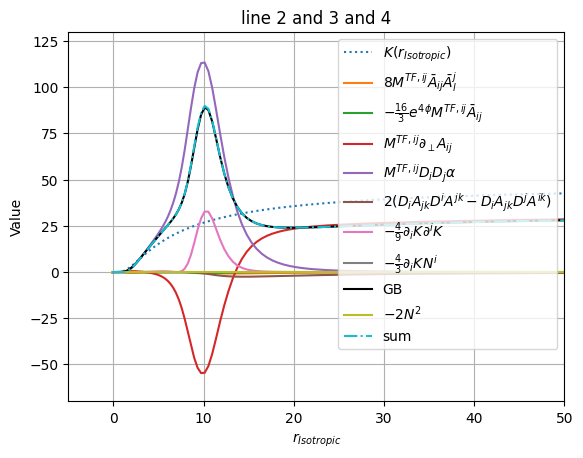

In [12]:
idx= -1 # time index
#idx = 0 #initial time 

ak = ak_list[idx] 
kkk = klist[idx]

dadt_perper = dadt_list[idx] 
DkDl_lapse_Katy = DkDl_lapse_Katy_list[idx]

D_diff = D_difference[idx] 
D_1 = D_1list[idx]
D_2 = D_1list[idx]
d1K_N_U_item = d1K_N_U[idx]
ff = finalfour[idx]
ff2 = finalfour2[idx]

Gausser = Gaur[idx]

som = ak + kkk +dadt_perper + DkDl_lapse_Katy + D_diff +  d1K_N_U_item + ff + ff2

plt.plot(r, Kretschmann(iso_to_sz(r))*r**6, label=r"$K(r_{Isotropic})$", linestyle=':')

plt.plot(r, ak*r**6, label = r"8$M^{TF, ij} \bar{A}_{ij}\bar{A}^j_l$")
plt.plot(r, kkk*r**6, label = r"$ -\frac{16}{3} e^{4\phi} M^{TF, ij}\bar{A}_{ij}  $")
plt.plot(r, dadt_perper*r**6, label = r"$M^{TF, ij} \partial_{\perp}A_{ij}$")
plt.plot(r, DkDl_lapse_Katy*r**6, label = r"$M^{TF, ij}D_i D_j \alpha$")
plt.plot(r, D_diff*r**6, label = r"$2(D_{i}A_{jk}D^{i}A^{jk}-D_{i}A_{jk}D^{j}A^{ik})$")
plt.plot(r, ff*r**6, label = r"$-\frac{4}{9}\partial_i K \partial^i K$")
plt.plot(r, ff2*r**6, label = r"$-\frac{4}{3}\partial_i K N^i $")
plt.plot(r, Gausser*r**6, label = 'GB', linestyle="-", color="black")
plt.plot(r, -d1K_N_U_item*r**6, label = r"$-2N^2$", linestyle="-")
plt.plot(r, som*r**6, label = 'sum', linestyle="-.")




#plt.plot(r, Gausser*r**6, label = 'GB', linestyle="-")

plt.title("line 2 and 3 and 4")
plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend(loc='best', fontsize=10)
'''plt.xlim(-0.1,2)
plt.ylim(-10,1200)'''

plt.xlim(-5,50)
plt.ylim(-70,130)
plt.grid()

# Hamilton value Vs Trace $M_{ij}$

(-1.8, 0.3)

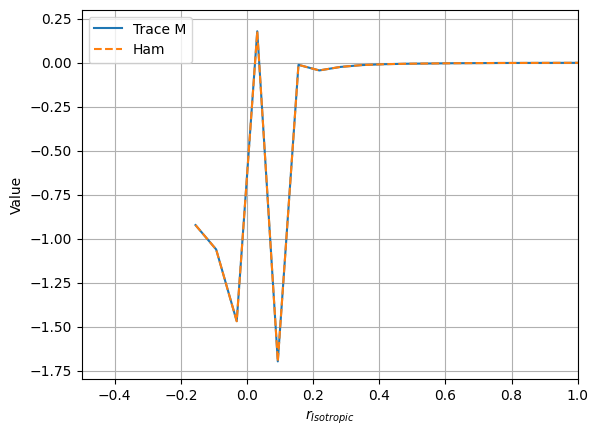

In [13]:
idx= -1
ham = Hamilton[idx]
TM = Trace_M_list[idx]

plt.plot(r, TM, label="Trace M")
plt.plot(r, ham, label="Ham",linestyle='--')

plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.xlim(-0.5, 1)
plt.ylim(-1.8, 0.3)

In [14]:
print(len(Hamilton))
print(len(Trace_M_list))

2414
2414


# Momentum value vs $N_i$

(-0.25, 0.25)

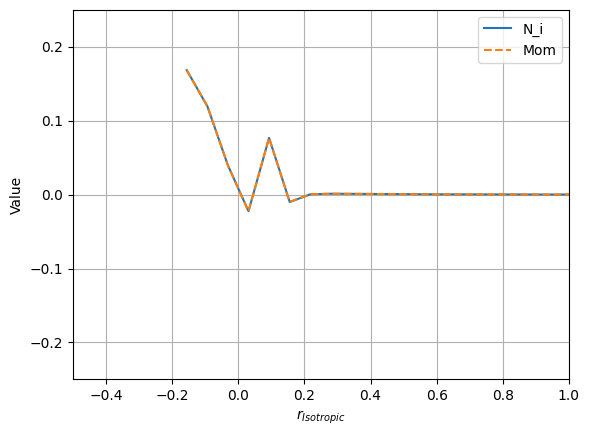

In [15]:
idx= -1
Mom = Momentum[idx]
N = Ennn[idx]

N_lister = []
for i in range(len(N)):
    N_lister.append(N[i][0])

Mom_lister = []
for i in range(len(Mom)):
    Mom_lister.append(Mom[i][0])

plt.plot(r, N_lister, label="N_i")
plt.plot(r, Mom_lister, label="Mom",linestyle='--')

plt.xlabel('$r_{Isotropic}$')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.xlim(-0.5, 1)
plt.ylim(-0.25, 0.25)